# Lending Sales Performance Analysis

**Business question:** a consumer-lending company sells point-of-sale loans through a network of 150 sales locations.
Management wants to know **how the network is performing against target, which locations are underperforming, *why*, and how much revenue is at stake.**

> ⚠️ **All data in this project is synthetic.** It was generated with `src/generate_data.py` to mimic the structure of a
> real lending sales network. No real company, customer or employee data is used.

**Contents**
1. Setup & data quality checks
2. Network KPIs
3. Monthly trend vs target
4. Weekday pattern
5. Product & region performance
6. Location segmentation
7. Underperformers: root cause & revenue gap
8. New-agent ramp-up
9. Key findings & recommendations

## 1. Setup & data quality checks

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB = ROOT / "data" / "lending.db"
SQL = ROOT / "sql"
IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)

con = sqlite3.connect(DB)

def run_sql(file_name, statement=0):
    """Run one statement from a .sql file in the sql/ folder and return a DataFrame."""
    text = (SQL / file_name).read_text()
    statements = [s for s in text.split(";") if any(l.strip() and not l.strip().startswith("--") for l in s.splitlines())]
    return pd.read_sql(statements[statement], con)

# Chart style
TEAL, TEAL_LIGHT, GREY, RED, AMBER = "#0f766e", "#99f6e4", "#a8a29e", "#dc2626", "#d97706"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
pd.set_option("display.float_format", "{:,.1f}".format)

In [2]:
tables = ["products", "locations", "agents", "applications", "targets"]
pd.DataFrame({t: [pd.read_sql(f"SELECT COUNT(*) n FROM {t}", con).n[0]] for t in tables}, index=["rows"]).T

,rows
products,4
locations,150
agents,372
applications,83892
targets,900


In [3]:
apps = pd.read_sql("SELECT * FROM applications", con, parse_dates=["application_date"])
apps.head()

,application_id,application_date,agent_id,location_id,product_id,requested_amount_egp,decision,is_disbursed,disbursed_amount_egp
0,APP0000001,2026-05-15,AG0001,LOC001,P3,"19,900.0",Approved,1,"16,600.0"
1,APP0000002,2026-05-16,AG0001,LOC001,P3,"36,700.0",Approved,1,"27,200.0"
2,APP0000003,2026-05-17,AG0001,LOC001,P2,"19,600.0",Approved,1,"14,200.0"
3,APP0000004,2026-05-17,AG0001,LOC001,P2,"33,100.0",Rejected,0,0.0
4,APP0000005,2026-05-17,AG0001,LOC001,P2,"26,600.0",Rejected,0,0.0


In [4]:
checks = {
    "date range": f"{apps.application_date.min():%Y-%m-%d} to {apps.application_date.max():%Y-%m-%d}",
    "missing values": int(apps.isna().sum().sum()),
    "duplicate application_id": int(apps.application_id.duplicated().sum()),
    "disbursed but not approved": int(((apps.is_disbursed == 1) & (apps.decision != "Approved")).sum()),
    "disbursed flag without amount": int(((apps.is_disbursed == 1) & (apps.disbursed_amount_egp <= 0)).sum()),
    "orphan agent_id": int((~apps.agent_id.isin(pd.read_sql("SELECT agent_id FROM agents", con).agent_id)).sum()),
}
pd.Series(checks, name="result").to_frame()

,result
date range,2026-01-01 to 2026-06-30
missing values,0
duplicate application_id,0
disbursed but not approved,0
disbursed flag without amount,0
orphan agent_id,0


All integrity checks pass: no missing values, no duplicates, and the funnel logic (approved → disbursed) is consistent.

## 2. Network KPIs  
`sql/01_kpi_overview.sql`

In [5]:
kpi = run_sql("01_kpi_overview.sql")
kpi.T.rename(columns={0: "value"})

,value
applications,"83,892.0"
approved,"53,741.0"
disbursed_loans,"48,690.0"
approval_rate_pct,64.1
approved_to_disbursed_pct,90.6
disbursed_egp_m,"1,278.7"
avg_ticket_egp,"26,263.0"
active_locations,150.0
active_agents,372.0


## 3. Monthly trend vs target  
`sql/02_monthly_trend.sql`

,month,applications,approval_rate_pct,disbursed_egp_m,target_egp_m,achievement_pct,loans_per_agent,mom_growth_pct
0,2026-01,12728,64.2,197.7,228.1,86.7,25.0,NaN
1,2026-02,11091,64.9,170.3,199.2,85.5,20.7,-13.8
2,2026-03,12045,64.5,185.6,204.6,90.7,20.8,9.0
3,2026-04,15739,63.9,240.3,248.5,96.7,26.1,29.5
4,2026-05,15766,63.8,237.1,243.2,97.5,24.5,-1.3
5,2026-06,16523,63.5,247.8,245.3,101.0,25.5,4.5


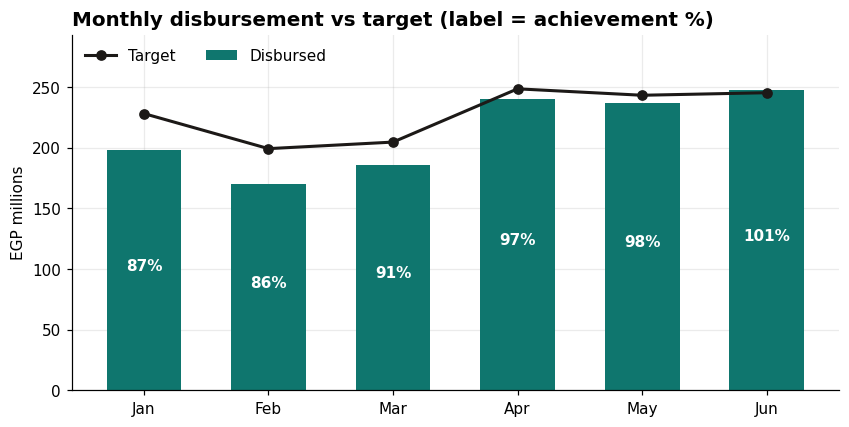

In [6]:
trend = run_sql("02_monthly_trend.sql")
display(trend)

fig, ax = plt.subplots(figsize=(9, 4.2))
x = range(len(trend))
ax.bar(x, trend.disbursed_egp_m, color=TEAL, width=0.6, label="Disbursed")
ax.plot(x, trend.target_egp_m, color="#1c1917", marker="o", lw=2, label="Target")
for i, r in trend.iterrows():
    ax.text(i, r.disbursed_egp_m / 2, f"{r.achievement_pct:.0f}%", ha="center", color="white", fontweight="bold")
ax.set_xticks(list(x), pd.to_datetime(trend.month).dt.strftime("%b"))
ax.set_ylabel("EGP millions")
ax.set_title("Monthly disbursement vs target (label = achievement %)")
ax.set_ylim(0, trend[["disbursed_egp_m", "target_egp_m"]].max().max() * 1.18)
ax.legend(frameon=False, loc="upper left", ncol=2)
plt.savefig(IMG / "01_monthly_trend.png"); plt.show()

## 4. Weekday pattern

,avg disbursed loans per day
weekday,
Sat,325.0
Sun,281.0
Mon,272.0
Tue,264.0
Wed,275.0
Thu,307.0
Fri,159.0


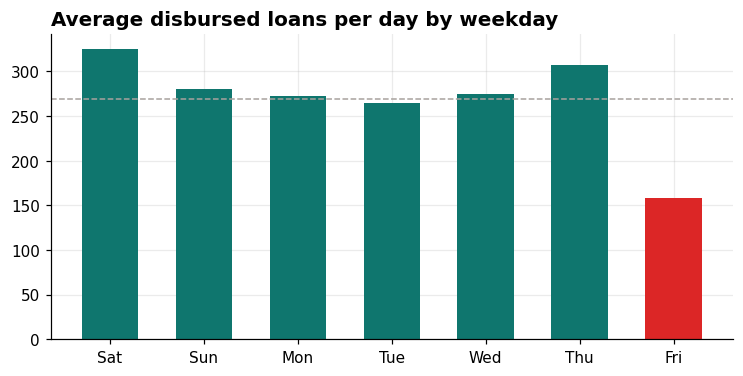

In [7]:
order = ["Sat", "Sun", "Mon", "Tue", "Wed", "Thu", "Fri"]
wd = (apps.assign(weekday=apps.application_date.dt.strftime("%a"))
          .groupby(["weekday", apps.application_date.dt.date]).is_disbursed.sum()
          .groupby("weekday").mean().reindex(order))
display(wd.round(0).to_frame("avg disbursed loans per day"))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(wd.index, wd.values, color=[RED if d == "Fri" else TEAL for d in wd.index], width=0.6)
ax.axhline(wd.mean(), color=GREY, ls="--", lw=1)
ax.set_title("Average disbursed loans per day by weekday")
plt.savefig(IMG / "02_weekday.png"); plt.show()

## 5. Product & region performance  
`sql/04_product_region_performance.sql`

,product_name,applications,approval_rate_pct,disbursed_egp_m,share_of_disbursement_pct,avg_ticket_egp
0,Furniture,21660,58.6,470.4,36.8,"40,767.0"
1,Home Appliances,24059,63.8,402.8,31.5,"28,968.0"
2,Mobile Phones,29978,68.7,303.3,23.7,"16,250.0"
3,Education,8195,62.1,102.3,8.0,"22,312.0"


,region,applications,approval_rate_pct,disbursed_egp_m,achievement_pct
0,Greater Cairo,35865,63.8,564.1,96.7
1,Canal,8344,64.9,108.0,95.2
2,Alexandria,21358,64.0,333.3,94.6
3,Upper Egypt,4387,62.6,66.2,86.3
4,Delta,13938,64.8,207.1,85.3


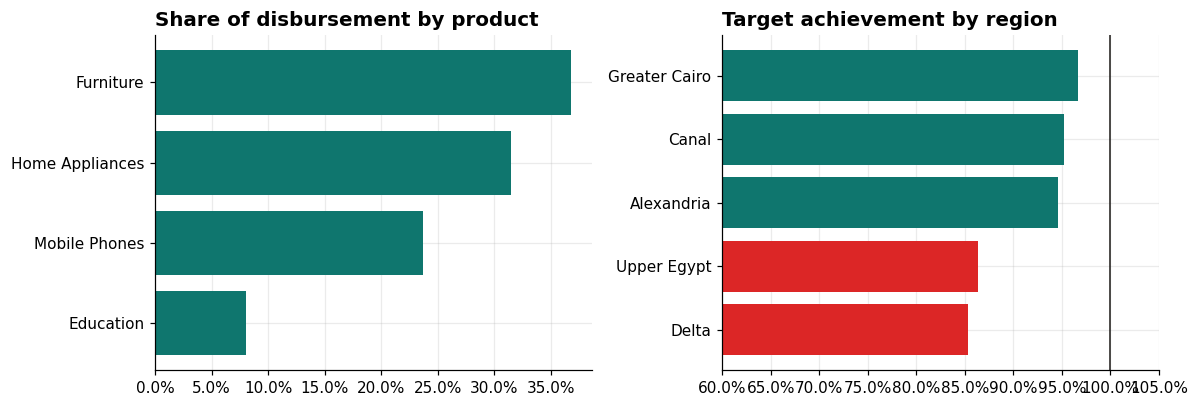

In [8]:
prod = run_sql("04_product_region_performance.sql", 0)
region = run_sql("04_product_region_performance.sql", 1)
display(prod, region)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(prod.product_name[::-1], prod.share_of_disbursement_pct[::-1], color=TEAL)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title("Share of disbursement by product")
r = region.sort_values("achievement_pct")
axes[1].barh(r.region, r.achievement_pct, color=[RED if v < 90 else TEAL for v in r.achievement_pct])
axes[1].axvline(100, color="#1c1917", lw=1)
axes[1].set_xlim(60, 105)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Target achievement by region")
plt.tight_layout(); plt.savefig(IMG / "03_product_region.png"); plt.show()

## 6. Location segmentation  
`sql/03_location_scorecard.sql`

Each location is placed into a performance tier based on target achievement over the period:

| Tier | Rule |
|---|---|
| ⭐ Star | ≥ 110% of target |
| ✅ On track | 85% – 110% |
| 🔻 Underperforming | < 85% |

In [9]:
score = run_sql("03_location_scorecard.sql")
score["tier"] = pd.cut(score.achievement_pct, [-1, 85, 110, 1e9], labels=["Underperforming", "On track", "Star"], right=False)

tier_summary = (score.groupby("tier", observed=True)
                     .agg(locations=("location_id", "count"),
                          disbursed_egp_m=("disbursed_egp_m", "sum"),
                          avg_approval_pct=("approval_rate_pct", "mean"),
                          avg_loans_per_agent_month=("loans_per_agent_month", "mean")))
tier_summary["share_of_locations_pct"] = 100 * tier_summary.locations / tier_summary.locations.sum()
display(tier_summary)
score.head(10)

,locations,disbursed_egp_m,avg_approval_pct,avg_loans_per_agent_month,share_of_locations_pct
tier,,,,,
Underperforming,63,347.7,59.1,14.4,42.0
On track,46,430.2,65.8,22.2,30.7
Star,41,500.7,67.6,29.3,27.3


,location_id,region,location_type,agents,applications,approval_rate_pct,approved_to_disbursed_pct,disbursed_egp_m,target_egp_m,achievement_pct,loans_per_agent_month,achievement_rank,tier
0,LOC036,Greater Cairo,Electronics Store,1,503,66.6,92.5,6.9,4.1,170.6,51.7,1,Star
1,LOC146,Greater Cairo,Furniture Store,4,2661,58.5,91.7,51.6,33.1,155.8,59.5,2,Star
2,LOC107,Alexandria,Furniture Store,4,2387,63.6,91.6,50.4,33.6,149.9,58.0,3,Star
3,LOC006,Upper Egypt,Electronics Store,1,204,70.6,93.8,3.0,2.1,146.2,22.5,4,Star
4,LOC055,Delta,Mall Kiosk,1,293,68.9,91.6,4.2,2.9,143.3,30.8,5,Star
5,LOC056,Canal,Mall Kiosk,3,1124,69.4,93.1,15.1,10.8,140.2,40.3,6,Star
6,LOC015,Alexandria,Electronics Store,4,2168,65.2,92.7,29.6,21.3,138.8,54.6,7,Star
7,LOC095,Greater Cairo,Electronics Store,4,1266,69.6,91.6,18.0,13.1,137.3,33.6,8,Star
8,LOC010,Alexandria,Furniture Store,4,1212,58.6,93.4,23.7,17.6,134.9,27.6,9,Star
9,LOC029,Greater Cairo,Furniture Store,3,629,58.8,91.9,12.1,9.0,134.9,18.9,10,Star


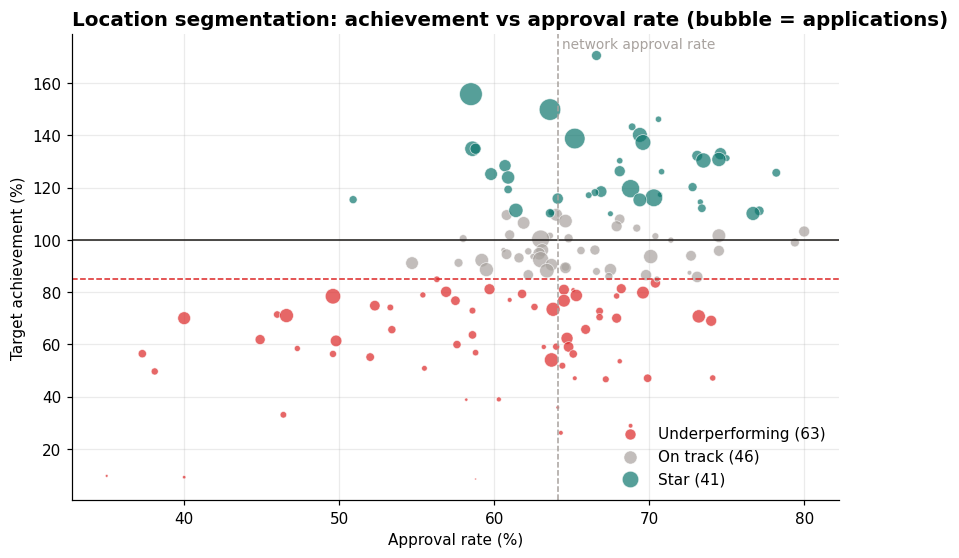

In [10]:
net_approval = kpi.approval_rate_pct[0]
colors = {"Star": TEAL, "On track": GREY, "Underperforming": RED}

fig, ax = plt.subplots(figsize=(9, 5.5))
for tier, g in score.groupby("tier", observed=True):
    ax.scatter(g.approval_rate_pct, g.achievement_pct, s=g.applications / 12, alpha=0.7,
               color=colors[tier], label=f"{tier} ({len(g)})", edgecolor="white", lw=0.5)
ax.axhline(100, color="#1c1917", lw=1)
ax.axhline(85, color=RED, lw=1, ls="--")
ax.axvline(net_approval, color=GREY, lw=1, ls="--")
ax.text(net_approval + 0.3, ax.get_ylim()[1] * 0.97, "network approval rate", color=GREY, fontsize=9)
ax.set_xlabel("Approval rate (%)"); ax.set_ylabel("Target achievement (%)")
ax.set_title("Location segmentation: achievement vs approval rate (bubble = applications)")
ax.legend(frameon=False, loc="lower right")
plt.savefig(IMG / "04_location_segmentation.png"); plt.show()

## 7. Underperformers: root cause & revenue gap  
`sql/06_underperformers_revenue_gap.sql`

In [11]:
under = run_sql("06_underperformers_revenue_gap.sql")
cause = (under.groupby("root_cause")
              .agg(locations=("location_id", "count"), gap_to_target_egp_m=("gap_to_target_egp_m", "sum"))
              .sort_values("gap_to_target_egp_m", ascending=False))
cause["share_of_gap_pct"] = 100 * cause.gap_to_target_egp_m / cause.gap_to_target_egp_m.sum()
print(f"Underperforming locations: {len(under)} of {len(score)}")
print(f"Total gap to target: EGP {under.gap_to_target_egp_m.sum():,.1f}M")
display(cause)
under.head(10)

Underperforming locations: 63 of 150
Total gap to target: EGP 186.9M


,locations,gap_to_target_egp_m,share_of_gap_pct
root_cause,,,
Low volume,40,102.0,54.6
Low approval,17,57.2,30.6
Disbursement leakage,6,27.7,14.8


,location_id,region,location_type,applications,approval_rate_pct,approved_to_disbursed_pct,achievement_pct,gap_to_target_egp_m,root_cause
0,LOC088,Alexandria,Furniture Store,1053,63.7,66.2,54.0,13.3,Disbursement leakage
1,LOC011,Greater Cairo,Mall Kiosk,740,64.7,92.7,62.3,5.9,Low volume
2,LOC076,Greater Cairo,Furniture Store,375,52.0,93.8,55.1,5.8,Low approval
3,LOC094,Greater Cairo,Electronics Store,565,64.8,90.4,59.0,5.4,Low volume
4,LOC148,Alexandria,Furniture Store,490,65.9,92.3,65.7,5.3,Low volume
5,LOC044,Greater Cairo,Furniture Store,848,40.0,90.3,70.0,4.8,Low approval
6,LOC092,Delta,Furniture Store,504,67.9,90.6,70.0,4.7,Low volume
7,LOC066,Alexandria,Electronics Store,900,73.2,73.7,70.7,4.6,Disbursement leakage
8,LOC021,Delta,Mall Kiosk,1007,63.8,91.9,73.4,4.5,Low volume
9,LOC143,Upper Egypt,Furniture Store,517,44.9,89.2,61.8,4.5,Low approval


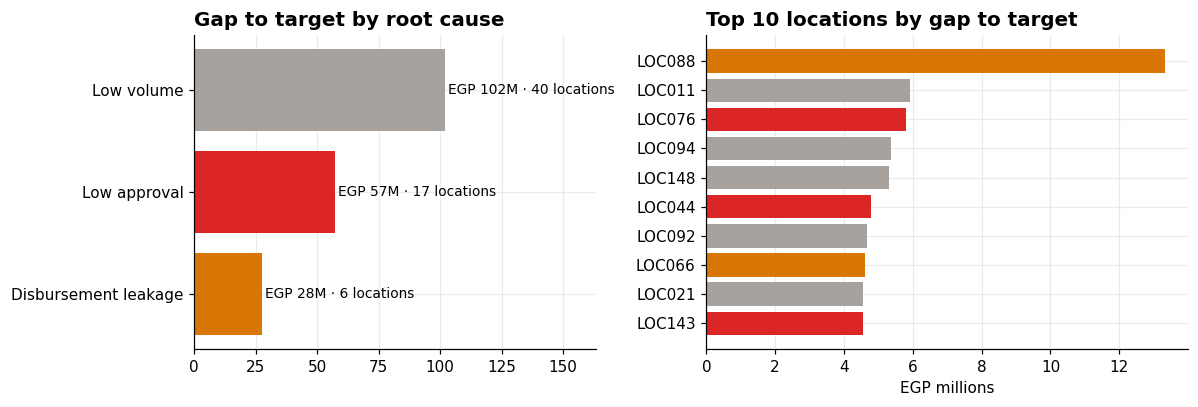

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.2]})
cc = {"Low volume": GREY, "Low approval": RED, "Disbursement leakage": AMBER}
c = cause.iloc[::-1]
axes[0].barh(c.index, c.gap_to_target_egp_m, color=[cc[i] for i in c.index])
for i, (v, n) in enumerate(zip(c.gap_to_target_egp_m, c.locations)):
    axes[0].text(v + 1, i, f"EGP {v:,.0f}M · {n} locations", va="center", fontsize=9)
axes[0].set_xlim(0, c.gap_to_target_egp_m.max() * 1.6)
axes[0].set_title("Gap to target by root cause")

top = under.nlargest(10, "gap_to_target_egp_m").iloc[::-1]
axes[1].barh(top.location_id, top.gap_to_target_egp_m, color=[cc[r] for r in top.root_cause])
axes[1].set_xlabel("EGP millions")
axes[1].set_title("Top 10 locations by gap to target")
plt.tight_layout(); plt.savefig(IMG / "05_root_cause_gap.png"); plt.show()

In [13]:
# Leakage deep-dive: how much would leakage locations add if they converted approvals like the network?
net_disb = kpi.approved_to_disbursed_pct[0] / 100
leak = pd.read_sql("""
    SELECT location_id,
           SUM(decision = 'Approved')                          AS approved,
           SUM(is_disbursed)                                   AS disbursed,
           SUM(disbursed_amount_egp) / SUM(is_disbursed)       AS avg_ticket
    FROM applications GROUP BY location_id""", con)
leak = leak[leak.location_id.isin(under.loc[under.root_cause == "Disbursement leakage", "location_id"])]
leak["recoverable_egp_m"] = (leak.approved * net_disb - leak.disbursed) * leak.avg_ticket / 1e6
print(f"Recoverable disbursement if leakage locations matched the network conversion: EGP {leak.recoverable_egp_m.sum():,.1f}M")

Recoverable disbursement if leakage locations matched the network conversion: EGP 10.9M


## 8. New-agent ramp-up  
`sql/05_agent_ramp_up.sql`

tenure_month,agents,active_agent_days,loans_per_active_day
0,91,1157,0.83
1,91,1373,0.88
2,80,1389,1.05
3,74,1263,1.16
4,65,868,1.16
5,50,829,1.23
6+,282,34490,1.21


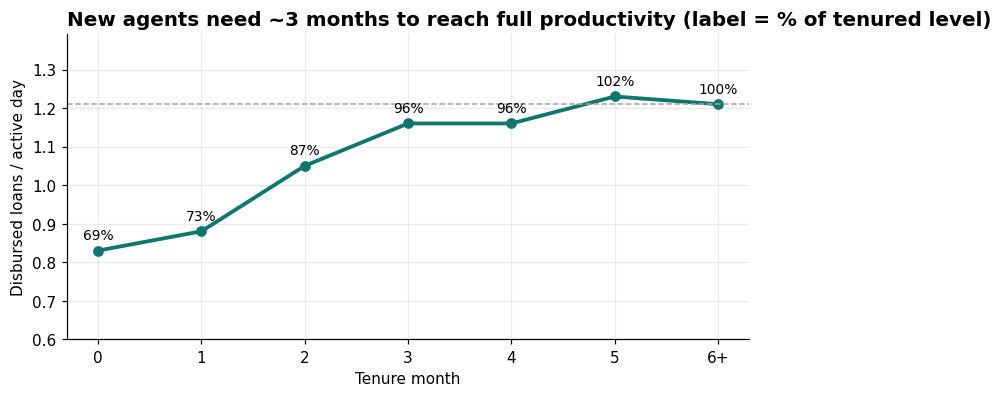

In [14]:
ramp = run_sql("05_agent_ramp_up.sql")
display(ramp.style.format({"loans_per_active_day": "{:.2f}"}).hide(axis="index"))
full = ramp.loc[ramp.tenure_month == "6+", "loans_per_active_day"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ramp.tenure_month, ramp.loans_per_active_day, marker="o", color=TEAL, lw=2.5)
ax.axhline(full, color=GREY, ls="--", lw=1)
for x, y in zip(ramp.tenure_month, ramp.loans_per_active_day):
    ax.text(x, y + 0.03, f"{100 * y / full:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0.6, full * 1.15)
ax.set_xlabel("Tenure month"); ax.set_ylabel("Disbursed loans / active day")
ax.set_title("New agents need ~3 months to reach full productivity (label = % of tenured level)")
plt.savefig(IMG / "06_agent_ramp_up.png"); plt.show()

## 9. Key findings & recommendations

### Key findings

| # | Finding | Evidence |
|---|---|---|
| 1 | **The network delivered 93% of its H1 target** (EGP 1,279M of 1,369M), and closed the gap over time | Achievement rose from 86–91% in Q1 to 101% in June |
| 2 | **42% of locations (63 of 150) are underperforming** and account for an **EGP 187M gap to target** | Location scorecard + underperformer query |
| 3 | **Low volume is the biggest driver** (40 locations, EGP 102M) — the funnel works, but not enough applications come in | Approval and disbursement rates in line with network |
| 4 | **Low approval** hits 17 locations (EGP 57M) — customers apply but don't qualify, often in furniture stores where approval is lowest (59%) | Root-cause flag + product table |
| 5 | **Disbursement leakage** in 6 locations (EGP 28M): loans get approved but customers don't complete them. Fixing conversion alone recovers **~EGP 11M** | Leakage deep-dive |
| 6 | **Fridays are ~45% weaker** than other days (159 vs 287 loans/day) | Weekday analysis |
| 7 | **New agents start at ~69% of tenured productivity** and need about 3 months to reach full speed | Ramp-up query |
| 8 | **Delta (85%) and Upper Egypt (86%)** trail Greater Cairo (97%) on target achievement | Region table |

### Recommendations

1. **Low-volume locations → drive footfall and lead capture:** partner in-store promotions, activate agents on Thursday/Saturday peaks, review staffing vs. traffic.
2. **Low-approval locations → improve lead quality:** pre-screening checklist for agents, coaching on eligibility rules, and push higher-approval products where the store mix allows.
3. **Leakage locations → follow up on approved-not-disbursed customers** within 24–48 hours; track *approved → disbursed %* weekly on the dashboard.
4. **Fridays → reduce the dip** with Friday-specific incentives or shifted shift coverage instead of expecting average-day output.
5. **New agents → structured 90-day onboarding** (buddy system, ramped targets) so they don't drag location achievement down in their first months.
6. **Targets → recalibrate** using location potential (traffic × agents × funnel rates); several locations are far above 130% or below 50%, which suggests targets, not just performance, need review.

### Next steps
- Rebuild the scorecard as an interactive **Power BI / Tableau** dashboard using the CSVs in `data/`.
- Add cohort tracking for agents and a monthly location-tier migration view (who moved up / down).